# Electrical Transformer Temperature Prediction (ETDataset)

The ETDataset (Electricity Transformer Dataset) provides long-term data collected from electrical transformer substations. Predicting Oil Temperature (OT) is crucial, as it is a key indicator of transformer health and extreme load. Accurate forecasts allow for the prevention of overheating, equipment depreciation, and optimization of electrical distribution.

In this project, we modeled the problem as a **Multivariate Regression** based on sliding windows. To capture short-, medium-, and long-term dependencies, we implemented and compared five state-of-the-art Deep Learning architectures.
The benchmark evaluates the Mean Squared Error (MSE), Mean Absolute Error (MAE), and Run Time of each model.

---
## 1. Importing Libraries and Configuring the Environment

In [1]:
import os
import copy
import math
import time
import random
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optuna for Hyperparameter Optimization
import optuna

pd.set_option('display.max_columns', None)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device Configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## 2. Data Ingestion (ETTh1)
We load the **ETTh1** variant (hourly resolution) from the local copy of the official repository (`data/ETDataset-main.zip`). If the zip is not present, the CSV is read directly from the official GitHub repository, so the notebook stays reproducible.

In [2]:
DATA_ZIP = os.path.join('..', 'data', 'ETDataset-main.zip')
CSV_IN_ZIP = 'ETDataset-main/ETT-small/ETTh1.csv'
DATA_URL = 'https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv'

if os.path.exists(DATA_ZIP):
    with zipfile.ZipFile(DATA_ZIP) as zf, zf.open(CSV_IN_ZIP) as f:
        data = pd.read_csv(f)
else:
    print("Local copy not found, reading ETTh1 from the official repository...")
    data = pd.read_csv(DATA_URL)

print(f"Dimensions of the dataset ETTh1: {data.shape}")
data.head()

Dimensions of the dataset ETTh1: (17420, 8)


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


---
## 3. Exploratory Data Analysis (EDA)
We visually inspect the target time series (`OT`) and check for correlations.

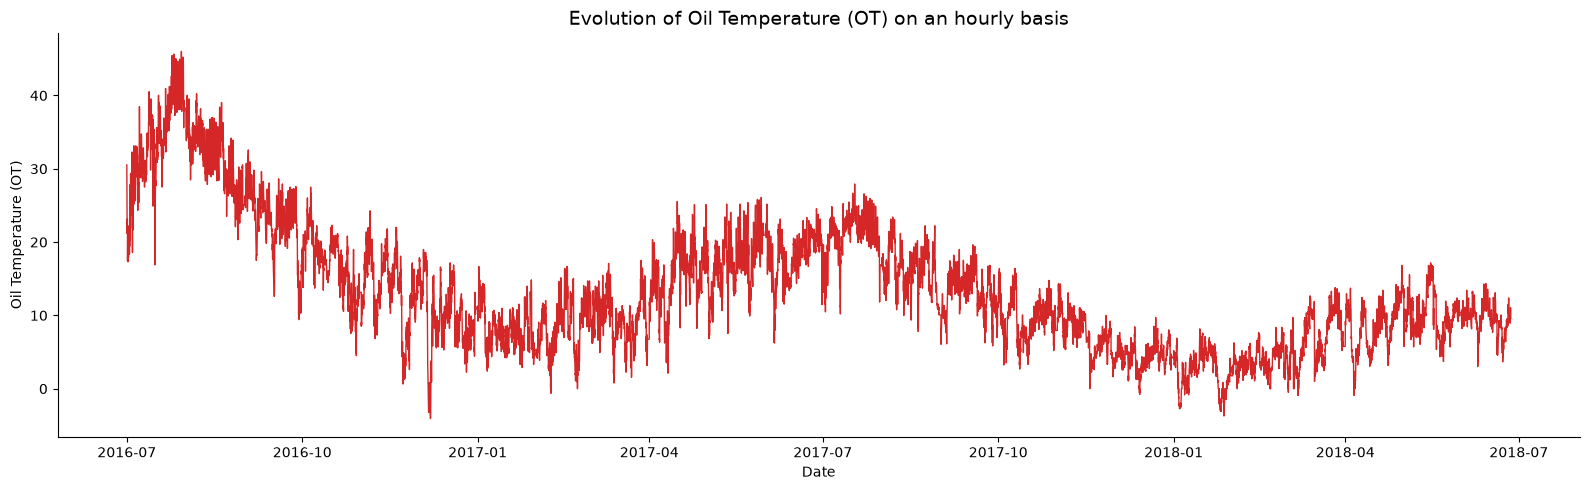

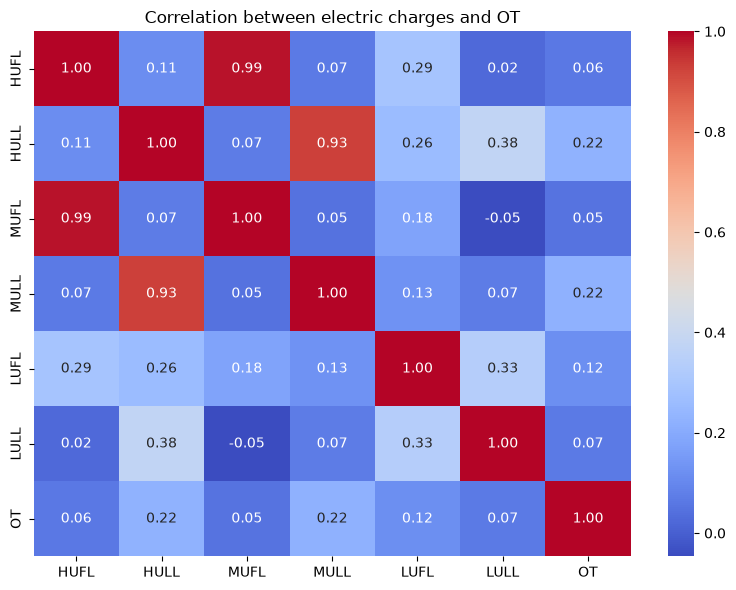

In [3]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

# Oil Temperature (OT) plot over time
plt.figure(figsize=(16, 5))
plt.plot(data.index, data['OT'], color='#d62728', linewidth=1)
plt.title('Evolution of Oil Temperature (OT) on an hourly basis', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Oil Temperature (OT)')
sns.despine()
plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation between electric charges and OT', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering and Preprocessing
We extract features from the date (month, day, time) and scale the numerical variables for neural network training.

In [4]:
# Extraction of temporal components to capture seasonality
data['month'] = data.index.month
data['day'] = data.index.day
data['hour'] = data.index.hour

# Predictor variables and Target
target_col = 'OT'
# Since oil temperature has strong autocorrelation, we include OT in the features because, in a time series, the target depends on its own history.
# The trick is that the model never sees the future value of OT during training, only its past values.
# 'date' is already the index, so every column is a feature.
feature_cols = data.columns.tolist()

# Chronological separation in Train (70%), Val (10%), Test (20%) - no shuffling to avoid leakage
n = len(data)
train_size = int(n * 0.7)
val_size = int(n * 0.1)

train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:train_size+val_size]
test_data = data.iloc[train_size+val_size:]

# Scaling (fitted on train only)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X = scaler_X.fit_transform(train_data[feature_cols])
val_X = scaler_X.transform(val_data[feature_cols])
test_X = scaler_X.transform(test_data[feature_cols])

train_y = scaler_y.fit_transform(train_data[[target_col]])
val_y = scaler_y.transform(val_data[[target_col]])
test_y = scaler_y.transform(test_data[[target_col]])

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Features (10): ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT', 'month', 'day', 'hour']
Train: 12194 | Val: 1742 | Test: 3484


---
## 5. Sequence Generation (Sliding Windows)
We transform the series into sequences of time length `seq_length` to predict the next value (`pred_length=1`).

The validation and test windows take their first `seq_length` hours of context from the end of the previous split. Those are past observations (inputs only), so there is no leakage, and every timestamp of the val/test periods gets a prediction.

In [5]:
def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i + seq_length])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

SEQ_LENGTH = 48 # We used 48 hours of history as context.

X_train_seq, y_train_seq = create_sequences(train_X, train_y, SEQ_LENGTH)
X_val_seq, y_val_seq = create_sequences(np.vstack([train_X[-SEQ_LENGTH:], val_X]),
                                        np.vstack([train_y[-SEQ_LENGTH:], val_y]), SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(np.vstack([val_X[-SEQ_LENGTH:], test_X]),
                                          np.vstack([val_y[-SEQ_LENGTH:], test_y]), SEQ_LENGTH)

batch_size = 256

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                        torch.tensor(y_train_seq, dtype=torch.float32)),
                          batch_size=batch_size, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_seq, dtype=torch.float32),
                                      torch.tensor(y_val_seq, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32),
                                       torch.tensor(y_test_seq, dtype=torch.float32)),
                         batch_size=batch_size, shuffle=False)

print(f"Train sequences: X={X_train_seq.shape}, y={y_train_seq.shape}")
print(f"Val sequences:   X={X_val_seq.shape}, y={y_val_seq.shape}")
print(f"Test sequences:  X={X_test_seq.shape}, y={y_test_seq.shape}")

Train sequences: X=(12146, 48, 10), y=(12146, 1)
Val sequences:   X=(1742, 48, 10), y=(1742, 1)
Test sequences:  X=(3484, 48, 10), y=(3484, 1)


---
## 6. Modern Deep Learning Architectures
Design and implementation of 5 high-performance architectures in PyTorch adapted for time series regression.

In [6]:
n_features = X_train_seq.shape[2] 

# Positional Encoding essential for Transformers
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [Batch, Seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return x

# 1. LSTM with Attention (Baseline)
class LSTMAttention(nn.Module):
    def __init__(self, hidden_dim=64, n_features=n_features):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(context)

# 2. Vanilla Transformer 
class VanillaTransformer(nn.Module):
    def __init__(self, n_features=n_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x) 
        out = self.transformer(x)
        out = out.mean(dim=1) 
        return self.fc(out)

# 3. DLinear (Decomposition Linear) 
class moving_avg(nn.Module):
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)
    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size // 2), 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        return x.permute(0, 2, 1)

class series_decomp(nn.Module):
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)
    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean

class DLinear(nn.Module):
    def __init__(self, seq_len=SEQ_LENGTH, n_features=n_features):
        super().__init__()
        self.seq_len = seq_len
        self.decomposition = series_decomp(25)
        self.Linear_Seasonal = nn.Linear(seq_len, 1)
        self.Linear_Trend = nn.Linear(seq_len, 1)
        self.combine = nn.Linear(n_features, 1)

    def forward(self, x):
        seasonal_init, trend_init = self.decomposition(x)
        seasonal_init = seasonal_init.permute(0,2,1)
        trend_init = trend_init.permute(0,2,1)
        
        seasonal_out = self.Linear_Seasonal(seasonal_init).squeeze(-1)
        trend_out = self.Linear_Trend(trend_init).squeeze(-1)
    
        x = seasonal_out + trend_out 
        return self.combine(x) 

# 4. PatchTST (Patch Time Series Transformer)
class PatchTST(nn.Module):
    def __init__(self, seq_len=SEQ_LENGTH, patch_len=12, stride=12, n_features=n_features, d_model=64, nhead=4):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.num_patches = int((seq_len - patch_len) / stride + 1)
        
        self.patch_proj = nn.Linear(patch_len * n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride) 
        B, num_patches, n_feat, P = patches.shape
        patches = patches.reshape(B, num_patches, n_feat * P)
        
        x_t = self.patch_proj(patches)
        x_t = self.pos_encoder(x_t) 
        out = self.transformer(x_t)
        out = out.mean(dim=1)
        return self.head(out)

# 5. ConvTransformer (Hybrid)
class ConvTransformer(nn.Module):
    def __init__(self, n_features=n_features, d_model=64, nhead=4):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=n_features, out_channels=d_model, kernel_size=3, padding=1)
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = F.relu(self.conv(x))
        x = x.permute(0, 2, 1) 
        x = self.pos_encoder(x) 
        
        out = self.transformer(x)
        out = out.mean(dim=1)
        return self.fc(out)

---
## 7. Hyperparameter Optimization (Optuna)
We apply Optuna (TPE sampler) to find the best learning rate for the **DLinear** model. DLinear is the cheapest model to train, so the search stays fast; the learning rate found is then reused for every architecture in the benchmark to compare them under the same training budget.

In [7]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    model = DLinear().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Short 2-epoch training to rank candidate learning rates
    for epoch in range(2):
        model.train()
        for x_b, y_b in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x_b.to(device)), y_b.to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_b, y_b in val_loader:
            loss = criterion(model(x_b.to(device)), y_b.to(device))
            val_loss += loss.item()

    return val_loss / len(val_loader)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20)
best_lr = study.best_params['lr']
print(f"Best Learning Rate (LR) found: {best_lr:.5f} | Val MSE: {study.best_value:.4f}")

Best Learning Rate (LR) found: 0.00955 | Val MSE: 0.0068


---
## 8. Benchmark Training Loop
We evaluate all models with the same training loop (Adam + MSE loss + Early Stopping on the validation loss) and record the regression metrics (MSE, MAE, R²) and the total training time of each model.

A **naive persistence baseline** (`OT(t) = OT(t-1)`) is added to the benchmark. For one-step-ahead forecasting of a highly autocorrelated series it is the reference any model has to beat to be useful.

In [8]:
def train_evaluate_regression(model, name, train_loader, val_loader, epochs=25, lr=best_lr, patience=5):
    print(f"\n{'='*40}\nTraining: {name}\n{'='*40}")
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    no_improve = 0
    best_state = None
    start_time = time.time()

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(x_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_mean = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                preds = model(x_b)
                loss = criterion(preds, y_b)
                val_loss += loss.item()

        val_mean = val_loss / len(val_loader)

        # Early Stopping Logic
        if val_mean < best_val_loss:
            best_val_loss, no_improve = val_mean, 0
            # deepcopy: state_dict() returns references to the live weights,
            # without a copy the "best" state would keep changing with training
            best_state = copy.deepcopy(model.state_dict())
            status = "Saved"
        else:
            no_improve += 1
            status = ""

        print(f"Epoch {epoch:2d} | Train MSE Loss: {train_mean:.4f} | Val MSE Loss: {val_mean:.4f} {status}")

        if no_improve >= patience:
            print(f"Early stopping activated at epoch {epoch}")
            break

    execution_time = time.time() - start_time
    model.load_state_dict(best_state)

    return model, execution_time

# Standardized inference function: returns true and predicted values in the original scale (°C).
def test_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            preds = model(x_b.to(device))
            y_true.extend(y_b.numpy())
            y_pred.extend(preds.cpu().numpy())

    # Return to original scale for interpretable metrics
    y_true_unscaled = scaler_y.inverse_transform(np.array(y_true).reshape(-1, 1))
    y_pred_unscaled = scaler_y.inverse_transform(np.array(y_pred).reshape(-1, 1))

    return y_true_unscaled, y_pred_unscaled


# Initialize Models
models = {
    "LSTM-Attention": LSTMAttention().to(device),
    "Vanilla Transformer": VanillaTransformer().to(device),
    "PatchTST": PatchTST().to(device),
    "DLinear": DLinear().to(device),
    "ConvTransformer": ConvTransformer().to(device)
}

# Run Benchmark
benchmark_results = []
predictions_dict = {}

for name, model in models.items():
    trained_model, exec_time = train_evaluate_regression(model, name, train_loader, val_loader)
    y_true, y_pred = test_model(trained_model, test_loader)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    benchmark_results.append({
        'Model': name,
        'MSE': mse,
        'MAE': mae,
        'R2 Score': r2,
        'Time (s)': exec_time
    })

    predictions_dict[name] = {'y_true': y_true, 'y_pred': y_pred}

# Naive persistence baseline: the prediction for hour t is the observed OT at hour t-1
y_true_naive = test_data[target_col].values.reshape(-1, 1)
y_pred_naive = np.concatenate([val_data[target_col].values[-1:],
                               test_data[target_col].values[:-1]]).reshape(-1, 1)
# Sanity check: the test sequences are aligned 1:1 with the test timestamps
assert np.allclose(y_true_naive, y_true, atol=1e-3)

benchmark_results.append({
    'Model': 'Naive (persistence)',
    'MSE': mean_squared_error(y_true_naive, y_pred_naive),
    'MAE': mean_absolute_error(y_true_naive, y_pred_naive),
    'R2 Score': r2_score(y_true_naive, y_pred_naive),
    'Time (s)': 0.0
})

df_results = pd.DataFrame(benchmark_results)


Training: LSTM-Attention


Epoch  0 | Train MSE Loss: 0.1858 | Val MSE Loss: 0.1918 Saved


Epoch  1 | Train MSE Loss: 0.0635 | Val MSE Loss: 0.1009 Saved


Epoch  2 | Train MSE Loss: 0.0200 | Val MSE Loss: 0.0221 Saved


Epoch  3 | Train MSE Loss: 0.0153 | Val MSE Loss: 0.0180 Saved


...

Epoch  5 | Train MSE Loss: 0.0199 | Val MSE Loss: 0.0170 


Epoch  6 | Train MSE Loss: 0.0199 | Val MSE Loss: 0.0162 


Epoch  7 | Train MSE Loss: 0.0194 | Val MSE Loss: 0.0187 


Epoch  8 | Train MSE Loss: 0.0181 | Val MSE Loss: 0.0234 


Epoch  9 | Train MSE Loss: 0.0167 | Val MSE Loss: 0.0128 
Early stopping activated at epoch 9


---
## 9. Results and Comparative Graphs
We compare accuracy (MAE, MSE, R²) and computational efficiency (training time) against the naive baseline. Finally, we visualize the predictions of the best model against the actual values.

,Model,MSE,MAE,R2 Score,Time (s)
0,DLinear,0.399441,0.435978,0.966362,6.262292
1,Naive (persistence),0.427957,0.448086,0.963960,0.000000
2,Vanilla Transformer,0.600526,0.604132,0.949427,16.313207
3,LSTM-Attention,0.732627,0.648802,0.938303,8.961827
4,ConvTransformer,0.946362,0.747357,0.920303,10.534828
5,PatchTST,0.917751,0.753040,0.922713,13.199849


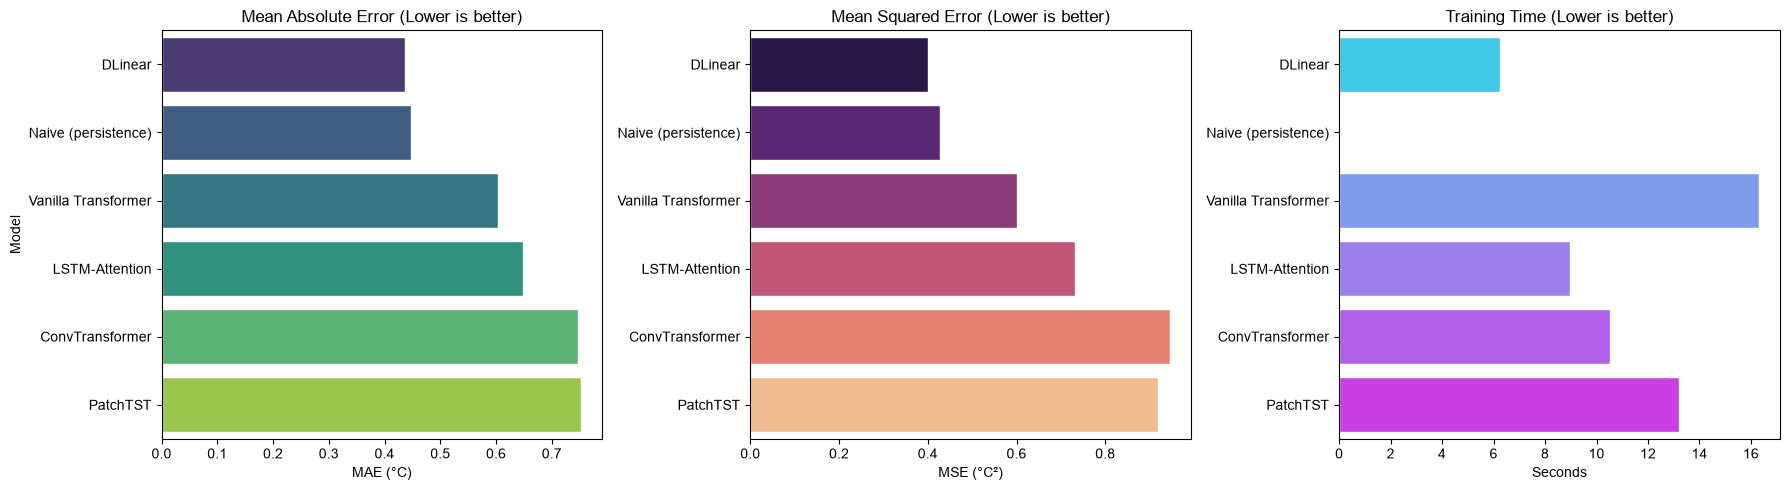

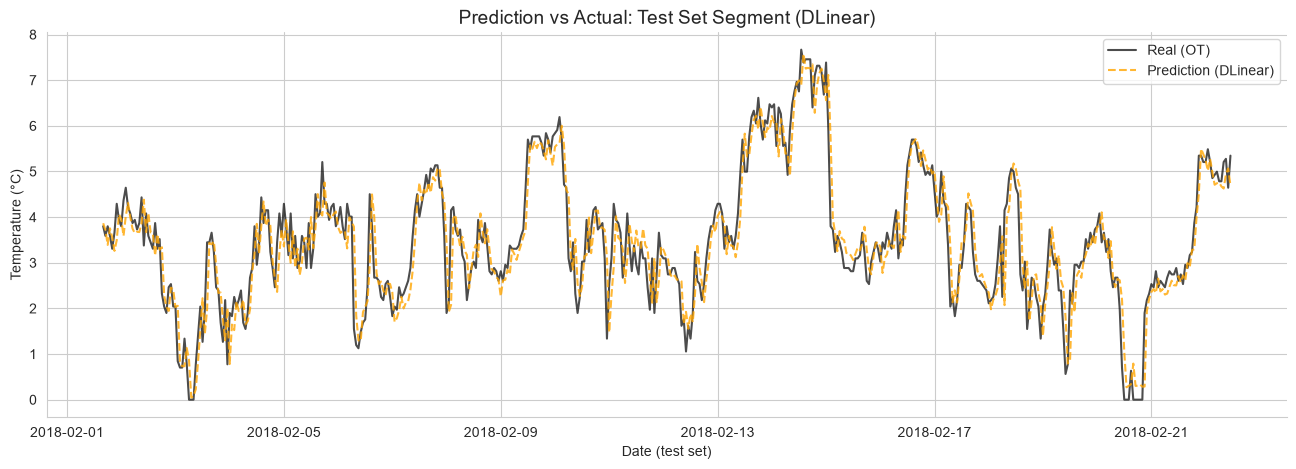

In [9]:
df_results = df_results.sort_values(by='MAE').reset_index(drop=True)
display(df_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style('whitegrid')

# Plot MAE
sns.barplot(data=df_results, x='MAE', y='Model', hue='Model', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Mean Absolute Error (Lower is better)')
axes[0].set_xlabel('MAE (°C)')

# Plot MSE
sns.barplot(data=df_results, x='MSE', y='Model', hue='Model', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Mean Squared Error (Lower is better)')
axes[1].set_xlabel('MSE (°C²)')
axes[1].set_ylabel('')

# Plot Time
sns.barplot(data=df_results, x='Time (s)', y='Model', hue='Model', palette='cool', legend=False, ax=axes[2])
axes[2].set_title('Training Time (Lower is better)')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Time Series Forecast Visualization (Best Deep Learning Model)
dl_results = df_results[df_results['Model'].isin(predictions_dict)]
best_model = dl_results.loc[dl_results['MAE'].idxmin(), 'Model']
best_y_true = predictions_dict[best_model]['y_true']
best_y_pred = predictions_dict[best_model]['y_pred']

# We take a segment to visualize clearly (e.g. 500 hours)
segment = 500
plt.figure(figsize=(16, 5))
plt.plot(test_data.index[:segment], best_y_true[:segment], label='Real (OT)', color='black', alpha=0.7)
plt.plot(test_data.index[:segment], best_y_pred[:segment], label=f'Prediction ({best_model})', color='orange', alpha=0.8, linestyle='--')
plt.title(f'Prediction vs Actual: Test Set Segment ({best_model})', fontsize=14)
plt.xlabel('Date (test set)')
plt.ylabel('Temperature (°C)')
plt.legend()
sns.despine()
plt.show()

---
## 10. Conclusions

* **DLinear is the best model** (MAE ≈ 0.44 °C, R² ≈ 0.966) and also the fastest to train: a simple trend/seasonal decomposition with linear layers is enough for one-step-ahead forecasting of this series.
* **The naive persistence baseline is very strong** (MAE ≈ 0.45 °C, R² ≈ 0.964). Oil temperature changes slowly from one hour to the next, so a high R² alone does not prove that a model is useful. Only DLinear beats the baseline; the attention-based models (Vanilla Transformer, LSTM-Attention, ConvTransformer, PatchTST) do not.
* The Transformer-based models are over-parameterized for a 48-hour window with ~12k training sequences, and they share the learning rate tuned on DLinear, which is not necessarily optimal for them.

**Next steps:** tune the hyperparameters of each architecture independently, evaluate longer forecasting horizons (24h / 48h ahead, where persistence degrades and deep models usually show their advantage), use cyclical encoding (sin/cos) for the time features, and report the average of several seeds.